In [ ]:
import matplotlib.pyplot as plt # import for graphing
from astropy.io import ascii # import for reading csv
import math #import for math
import numpy as np # import for stats
from scipy.optimize import curve_fit # import for curve fit

In [ ]:
#read in data
data = ascii.read('Lab 5.csv')
potential=data['Potential']
D_inner_T1=data['D_inner_T1']
D_inner_T2=data['D_inner_T2']
D_inner_T3=data['D_inner_T3']
D_inner_T4=data['D_inner_T4']
D_inner_T5=data['D_inner_T5']
D_outer_T1=data['D_outer_T1']
D_outer_T2=data['D_outer_T2']
D_outer_T3=data['D_outer_T3']
D_outer_T4=data['D_outer_T4']
D_outer_T5=data['D_outer_T5']

# average the 5 trials
D_inner=[]
for i in range(len(D_inner_T1)):
  D_inner.append(sum([D_inner_T1[i],D_inner_T2[i],D_inner_T3[i],D_inner_T4[i],D_inner_T5[i]])/5)

# standard deviation of the mean
D_inner_err=[]
for i in range(len(D_inner_T1)):
  D_inner_err.append(np.std([D_inner_T1[i],D_inner_T2[i],D_inner_T3[i],D_inner_T4[i],D_inner_T5[i]], ddof=1) / np.sqrt(5))

# average the 5 trials
D_outer=[]
for i in range(len(D_outer_T1)):
  D_outer.append(sum([D_outer_T1[i],D_outer_T2[i],D_outer_T3[i],D_outer_T4[i],D_outer_T5[i]])/5)

# standard deviation of the mean
D_outer_err=[]
for i in range(len(D_outer_T1)):
  D_outer_err.append(np.std([D_outer_T1[i],D_outer_T2[i],D_outer_T3[i],D_outer_T4[i],D_outer_T5[i]], ddof=1) / np.sqrt(5))

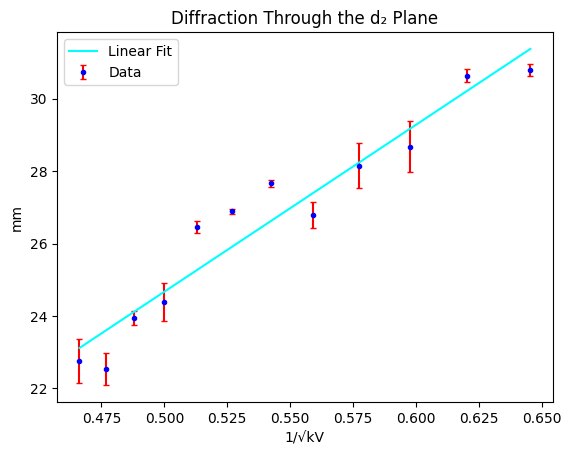

m=46.07±5.18 mm·√kV
b=2±3 mm


In [ ]:
#define linear fit
def lin_fit(x,m,b):
    return m*x+b

#perform linear fit
popt,pcov=curve_fit(lin_fit,(potential)**(-1/2),D_inner,absolute_sigma=True)
m,b=popt
m_err=np.sqrt((pcov[0,0]))
b_err=np.sqrt((pcov[1,1]))

#graph data
plt.errorbar((potential)**(-1/2),D_inner,color='blue',label='Data',ecolor='red',yerr=D_inner_err,fmt='.',capsize=2)

#graph fit
x_fit=np.linspace(min((potential)**(-1/2)),max((potential)**(-1/2)),100)
plt.plot(x_fit,lin_fit(x_fit,m,b),color='cyan',label='Linear Fit')

#create plot
plt.xlabel('1/√kV')
plt.ylabel('mm')
plt.title('Diffraction Through the d₂ Plane')
plt.legend()
plt.savefig('d_2_diffraction.pdf', format='pdf', bbox_inches='tight')
plt.show()

#print slope and intercept
print(f"m={m:.2f}±{m_err:.2f} mm·√kV")
print(f"b={b:.0f}±{b_err:.0f} mm")

In [ ]:
#define constants
h=6.626*10**-34
m_e=9.10938*10**-31
e=1.60217663*10**-19
L=0.13
L_err=0.002

#convert slope units
m=(m/1000)*(1000)**(1/2)
m_err=(m_err/1000)*(1000)**(1/2)

#calculate d value
d=(2*h*L)/(m*(2*m_e*e)**(1/2))
err_d=(((2*h)/(m*(2*m_e*e)**(1/2))*L_err)**2+((2*h*L)/(m**2*(2*m_e*e)**(1/2))*m_err)**2)**(1/2)
print(f'd₂={(d*10**12):.0f}±{(err_d*10**12):.0f} pm')

#calculate agreement
a=abs((213e-12 - d) / err_d)
print(f'agreement = {a:.2f}')

d₂=219±25 pm
agreement = 0.24


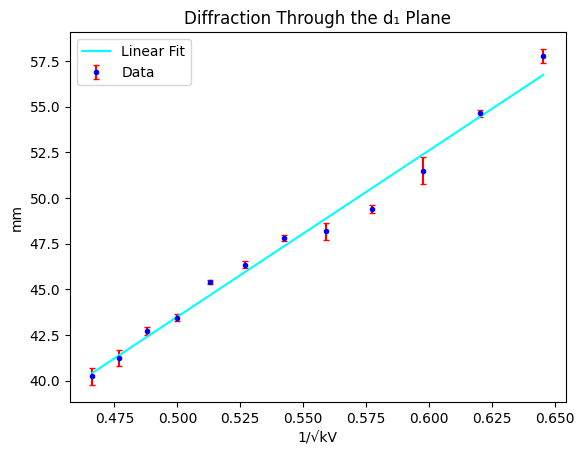

m=91±5 mm·√kV
b=-2±3 mm


In [ ]:
#perform linear fit
popt, pcov = curve_fit(lin_fit, (potential)**(-1/2), D_outer, absolute_sigma=True)
m=popt[0]
b=popt[1]
m_err=np.sqrt((pcov[0,0]))
b_err=np.sqrt((pcov[1,1]))

#plot data
plt.errorbar((potential)**(-1/2),D_outer, color='blue',label='Data',ecolor='red',yerr=D_outer_err,fmt='.',capsize=2)

#plot fit
x_fit = np.linspace(min((potential)**(-1/2)), max((potential)**(-1/2)), 100)
plt.plot(x_fit, lin_fit(x_fit, m,b), color='cyan', label='Linear Fit')

#create plot
plt.xlabel('1/√kV')
plt.ylabel('mm')
plt.title('Diffraction Through the d₁ Plane')
plt.legend()
plt.savefig('d_1_diffraction.pdf', format='pdf', bbox_inches='tight')
plt.show()

#print slope and intercept
print(f"m={m:.0f}±{m_err:.0f} mm·√kV")
print(f"b={b:.0f}±{b_err:.0f} mm")

In [ ]:
#convert units of slope
m=(m/1000)*(1000)**(1/2)
m_err=(m_err/1000)*(1000)**(1/2)

#calculate d
d=(2*h*L)/(m*(2*m_e*e)**(1/2))
err_d=(((2*h)/(m*(2*m_e*e)**(1/2))*L_err)**2+((2*h*L)/(m**2*(2*m_e*e)**(1/2))*m_err)**2)**(1/2)
print(f'd₁={(d*10**12):.0f}±{(err_d*10**12):.0f} pm')

#calculate agreement
a=abs((123e-12 - d) / err_d)
print(f'agreement = {a:.2f}')

d₁=111±7 pm
agreement = 1.88
